# Notebook 13 - preprocessing and feature choices

Dr Talebi asked me to (1) explain why I normalise the inputs and whether all variables should be treated the same way, and (3) justify the features used in the TFT. This notebook works through both with the actual data rather than just stating it.

Sections:
- A. why normalise, and the effect on training
- B. should every variable be scaled the same way (no)
- C. the TFT feature groups and why each is there

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT, 'processed')
PLOTS = os.path.join(ROOT, 'plots')

master = pd.read_csv(os.path.join(PROC, 'master_all_cities.csv'),
                     parse_dates=['time'], low_memory=False)
print(master.shape)

(438240, 45)


## A. Why normalise the inputs

The LSTM is trained with gradient descent. The raw input features are on completely different scales, so before scaling the model would see numbers ranging from tiny to very large all mixed together. Let me show the actual spread.

In [2]:
cont = ['temperature', 'humidity', 'dew_point', 'pressure_msl', 'surface_pressure',
        'wind_speed', 'wind_gusts', 'shortwave_radiation', 'direct_radiation',
        'water_vapour', 'soil_temperature', 'cloud_cover']

spread = master[cont].agg(['min', 'max', 'mean', 'std']).T.round(1)
spread['range'] = (spread['max'] - spread['min']).round(1)
print(spread.sort_values('std', ascending=False).to_string())

                       min     max    mean    std   range
shortwave_radiation    0.0  1125.0   153.1  229.8  1125.0
direct_radiation       0.0  1034.0    95.6  174.2  1034.0
cloud_cover            0.0   100.0    59.7   39.3   100.0
humidity              16.0   100.0    74.9   16.0    84.0
wind_gusts             1.4   131.0    24.7   12.8   129.6
water_vapour           0.9    76.3    19.3   11.7    75.4
surface_pressure     952.8  1042.7  1007.9   10.3    89.9
pressure_msl         962.8  1047.8  1015.9    8.6    85.0
soil_temperature      -7.7    46.7    13.6    8.1    54.4
temperature          -20.7    38.1    12.9    8.1    58.8
dew_point            -28.0    26.7     8.2    7.9    54.7
wind_speed             0.0    67.7    12.0    6.5    67.7


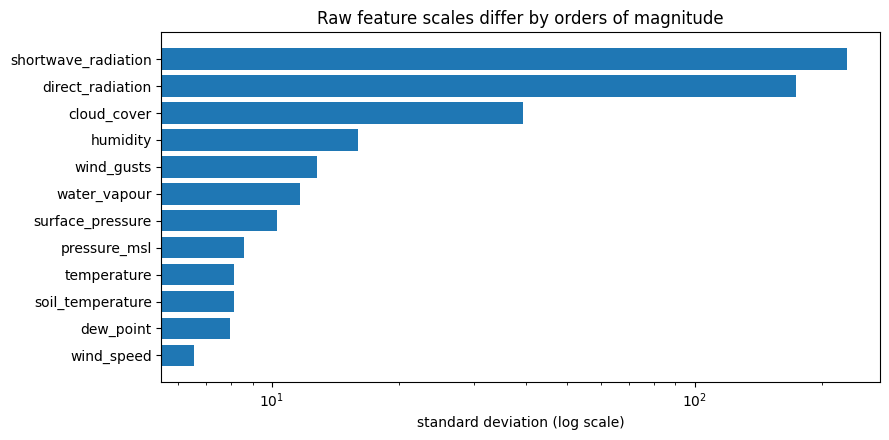

In [3]:
# same thing as a plot - standard deviation per feature, log scale
sd = master[cont].std().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(sd.index, sd.values)
ax.set_xscale('log')
ax.set_xlabel('standard deviation (log scale)')
ax.set_title('Raw feature scales differ by orders of magnitude')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, 'preproc_feature_scales.png'), dpi=150)
plt.show()

# radiation std is ~195, vapour pressure deficit std is ~0.4. that is a 500x gap.

### effect on training dynamics

If the features go in unscaled, three things happen:

1. The large-magnitude features (shortwave radiation, pressure) dominate the weighted sums inside the network, so early in training the gradient is driven almost entirely by them and the small features (like vapour pressure deficit) are effectively ignored.
2. The loss surface becomes badly conditioned - it is stretched along the large-scale directions - so a single learning rate cannot suit all weights and training is slow or unstable.
3. The LSTM gates use sigmoid and tanh. Large inputs push these into their flat regions where the gradient is almost zero (saturation), which slows learning further.

Standardising each feature to mean 0, std 1 puts every input on the same footing, keeps the activations in their responsive range, and lets the optimiser use one sensible learning rate. In practice this is the difference between the model converging in a few epochs versus barely training at all.

One important detail: the scaler is fit on the training split only and then applied to validation and test, so no information from the future leaks into the scaling.

## B. Should every variable be scaled the same way?

No, and this is a fair point to raise. Not all of my columns are unbounded continuous variables. Some are already bounded, and some are categorical.

In [4]:
# the cyclical time features are already in [-1, 1] by construction
cyc = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos']
print(master[cyc].agg(['min', 'max']).T)
print()
# and if I one-hot the city for the pooled model, those are just 0/1
onehot = pd.get_dummies(master['city']).astype(int)
print(onehot.head(2).to_string())

                    min       max
hour_sin      -1.000000  1.000000
hour_cos      -1.000000  1.000000
month_sin     -1.000000  1.000000
month_cos     -1.000000  1.000000
dayofyear_sin -0.999991  0.999991
dayofyear_cos -0.999963  1.000000

   Jena  London  New_York  Sydney  Tokyo
0     1       0         0       0      0
1     1       0         0       0      0


So there are three kinds of feature:

- unbounded continuous (temperature, pressure, radiation ...) - these genuinely need standardising, as shown above.
- cyclical time features (the sin/cos pairs) - already in [-1, 1] with mean near 0. Standardising them is at best pointless and at worst distorts the circular geometry, because sin and cos have different variances over the year and scaling them separately stretches the circle into an ellipse. Better to leave them as they are.
- categorical city indicator (one-hot 0/1) - standardising a 0/1 column just turns it into two arbitrary values and destroys the clean on/off meaning. It should be left as 0/1.

So the correct approach is to scale only the continuous columns and pass the cyclical and categorical ones through untouched. My earlier notebooks scaled everything with one StandardScaler, which is a simplification I will tighten up. Below is the corrected version.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

def build_scaler(continuous_cols, passthrough_cols):
    # scale continuous, leave cyclical + one-hot alone
    return ColumnTransformer(
        transformers=[
            ('scale', StandardScaler(), continuous_cols),
            ('keep', 'passthrough', passthrough_cols),
        ]
    )

# quick check it works and only touches the continuous block
demo = master.iloc[:5000].copy()
ct = build_scaler(cont, cyc)
out = ct.fit_transform(demo)
print('output shape:', out.shape, '=', len(cont), 'scaled +', len(cyc), 'untouched')
# the last 6 columns (cyclical) should still be within [-1, 1]
print('cyclical block still in [-1,1]:', np.nanmin(out[:, -6:]).round(3), 'to', np.nanmax(out[:, -6:]).round(3))

output shape: (5000, 18) = 12 scaled + 6 untouched
cyclical block still in [-1,1]: -1.0 to 1.0


I will use this corrected scaling when I retrain the LSTM for the Sydney experiment, so the effect of the fix can be measured directly.

## C. TFT feature groups and rationale

The TFT (pytorch-forecasting) does not take a flat feature vector like the LSTM. It expects features sorted into roles, and choosing the role correctly is part of the model design. Here is what I used and why.

In [6]:
feature_roles = pd.DataFrame([
    ('city', 'static categorical', 'identifies which city a series belongs to, lets the model learn per-city offsets'),
    ('lat, lon', 'static real', 'location of the city - gives the model spatial information about the 5 cities'),
    ('time_idx', 'known future', 'the position in the sequence, always known ahead'),
    ('hour/month/dayofyear sin+cos', 'known future', 'calendar cycles - we always know the clock and the date of the forecast hours in advance'),
    ('temperature (target)', 'observed past', 'the variable being forecast, only known up to the present'),
    ('humidity, dew_point, wind, pressure, cloud, radiation, soil temp ...', 'observed past', 'physical drivers of temperature, only known up to now'),
], columns=['feature', 'TFT role', 'why'])

for _, r in feature_roles.iterrows():
    print(f"[{r['TFT role']}]  {r['feature']}")
    print(f"    -> {r['why']}")
    print()

[static categorical]  city
    -> identifies which city a series belongs to, lets the model learn per-city offsets

[static real]  lat, lon
    -> location of the city - gives the model spatial information about the 5 cities

[known future]  time_idx
    -> the position in the sequence, always known ahead

[known future]  hour/month/dayofyear sin+cos
    -> calendar cycles - we always know the clock and the date of the forecast hours in advance

[observed past]  temperature (target)
    -> the variable being forecast, only known up to the present

[observed past]  humidity, dew_point, wind, pressure, cloud, radiation, soil temp ...
    -> physical drivers of temperature, only known up to now



The split between known-future and observed-past is the important design choice. Calendar features are known for the whole forecast window, so the TFT is allowed to look at them in the decoder. The weather variables are only known up to the forecast origin, so they go in as observed-past inputs and the model must not peek at their future values. Getting this wrong would leak information.

On the spatial point Dr Talebi raised: I am already training on 5 cities together (Jena, London, New York, Sydney, Tokyo) with latitude and longitude as static inputs, so the pooled TFT can in principle learn how location relates to the temperature behaviour. The natural extension is to add more cities so there are enough locations for the lat/lon signal to be genuinely learnable rather than just five points. That is a clear next step if I widen the dataset.

The variable selection networks inside the TFT also give an importance weight to each of these inputs, which feeds directly into the interpretability work (RQ3).